# Dataset exploration

Now that we cleaned up the dataset, it's time to start exploring it.

To start off we will first look at the data source to understand wind kind of data we are dealing with.

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import pathlib
from pathlib import Path

current_dir = Path.cwd()
data_file_path = current_dir.parent.parent / 'data_analysis' / 'sensor-readings-cleaned.csv'

# Load the data from the CSV file with pandas, specifying the correct encoding
data = pd.read_csv(data_file_path, encoding='utf-8')

# The unix_time values are already expressed in seconds.
data['timestamp'] = pd.to_datetime(data['unix_time'], unit='s')


As we cleaned all the unnecessary data, only the following columns are present in the dataset:
- `unix_time`: The timestamp of the reading in Unix time format.
- `timestamp`: The timestamp of the reading in human-readable format.
- `temperature_c`: The temperature reading in Celsius.
- `humidity_pct`: The humidity reading in percentage.
- `aqi`: The air quality index reading.
- `tvoc_ppb`: The total volatile organic compounds reading in parts per billion.
- `eco2_ppm`: The equivalent CO2 reading in parts per million.
- `ens_validity`: The validity of the environmental sensor reading.

## ENS160+AHT21 air quality sensor board

The measurement data is collected using the ENS160+AHT21 air quality sensor. The sensor is connected to an ESP32 microcontroller which collects the data and sends it to a server for storage and analysis.

There are multiple revisions of this board, so it's a bit difficult to find the exact board description, however the designs seems to be generally similar to the one shown below.

[Board description](https://docs.cirkitdesigner.com/component/e68d8a84-e8b6-41b4-95d8-87dbe74fadc9/ens160aht21)

The sensors located on the board are:
1. [ENS160](https://www.sciosense.com/wp-content/uploads/2023/12/ENS160-Datasheet.pdf) - digital multi-gas sensor solution, based on metal oxide (MOX) technology.
2. [AHT21](https://asairsensors.com/wp-content/uploads/2021/09/Data-Sheet-AHT21-Humidity-and-Temperature-Sensor-ASAIR-V1.0.03.pdf) - Humidity and Temperature Sensor.

### ENS160
The air quality parameters measured by the sensor are shown in the table below:

| Parameter | Range | Resolution | Unit | Description |
|-----------|-------|------------|------|-------------|
| TVOC | 0-65,000 | 1 | ppb |  VOCs are various types of hydrocarbons from mainly two sources: bio-effluents, i.e. odors from human respiration, transpiration and metabolism, and building material including furniture and household supplies. VOCs are known to cause eye irritation, headache, drowsiness or even dizziness – all summarized under the term Sick Building Syndrome (SBS). Various gases levels can be measured with this sensor model, but in current ESP32 firmware we focused on getting the overall TVOC value. |
| eCO2 | 400-65,000 | 1 | ppm | Carbon dioxide equivalent. Due to the proportionality between VOCs and -CO2 generated by humans, CO2-values historically served as an air quality indicator, reflecting the total amount of VOCs (=TVOC) produced by human respiration and transpiration. According to the sensor documentation, the TVOC and eCO2 values are correlated. |
| AQI-UBA | 0-5 | 1 | - | Air Quality Index. The AQI-UBA17 air quality index is derived from a guideline by the German Federal Environmental Agency based on a TVOC sum signal. Although a local, German guideline, it is referenced and adopted by many countries and organizations. |
| ENS validity signal | 0-3 | 1 | - | The ENS160 sensor provides a validity signal to indicate whether the sensor is ready to provide valid measurements. 0 - normal operation, 1 - warming up, 2 - initial, 3 - error (not valid output). The value can change after sensor restart (also due to ESP32 firmware bug), so we keep this value to keep track of the sensor status. Typically, only 0 ens status values will be used. |


### AHT21
The temperature and humidity sensor parameters are shown in the table below.

| Parameter | Range | Resolution | Unit | Description |
|-----------|-------|------------|------|-------------|
| Relative Humidity | 0-100 | 0.1 | %RH | Relative humidity is the ratio of the partial pressure of water vapor to the equilibrium vapor pressure of water at a given temperature. According to the sensor datasheet, the measurement accuracy is ±2%RH and can vary depending on the temperature. |
| Temperature | -40-120 | 0.1 | °C | Temperature measurement accuracy is ±0.1°C according to the sensor datasheet. |

## Measurement environment
The measurements were take in a typical indoor environment, with the sensor board placed on a table in a room with normal ventilation. At some data points the room was occupied but 1-2 people, while at other times the room was empty. The measurements were taken over a period of several days, with the sensor board powered on continuously. The sensor was located at around 1 meter distance from the window, and the window was opened at some points during the measurement period. 

## Sensor downtime
The sensor board was powered on continuously, but there were some periods of time when the sensor was not able to provide valid measurements. This was caused by the sensor maintenance (board assembly), or firmware issues.

The downtime periods can be seen on both the ENS160 and AHT21 sensor readings, as shown on the graphs below.

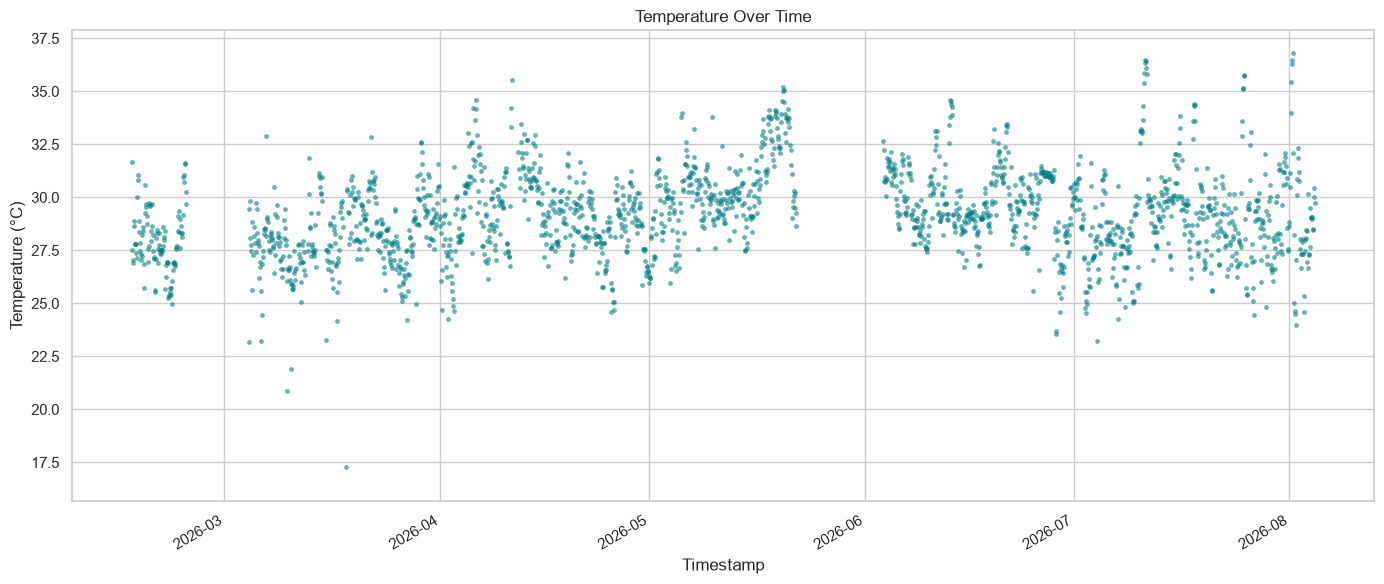

In [14]:
# Plot the temperature readings over time, sampling the data to avoid plotting too many points
temperature_data = data.dropna(subset=['temperature_c']).sort_values('timestamp')
max_points = 2_000
sample_step = max(1, len(temperature_data) // max_points)
plot_data = temperature_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(
    data=plot_data,
    x='timestamp',
    y='temperature_c',
    s=12,
    alpha=0.6,
    linewidth=0,
    color='#007f86',
    ax=ax,
)

ax.set_title('Temperature Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Temperature (°C)')
ax.set_ylim(temperature_data['temperature_c'].min() - 1, temperature_data['temperature_c'].max() + 1)
fig.autofmt_xdate()
fig.tight_layout()

plt.show()



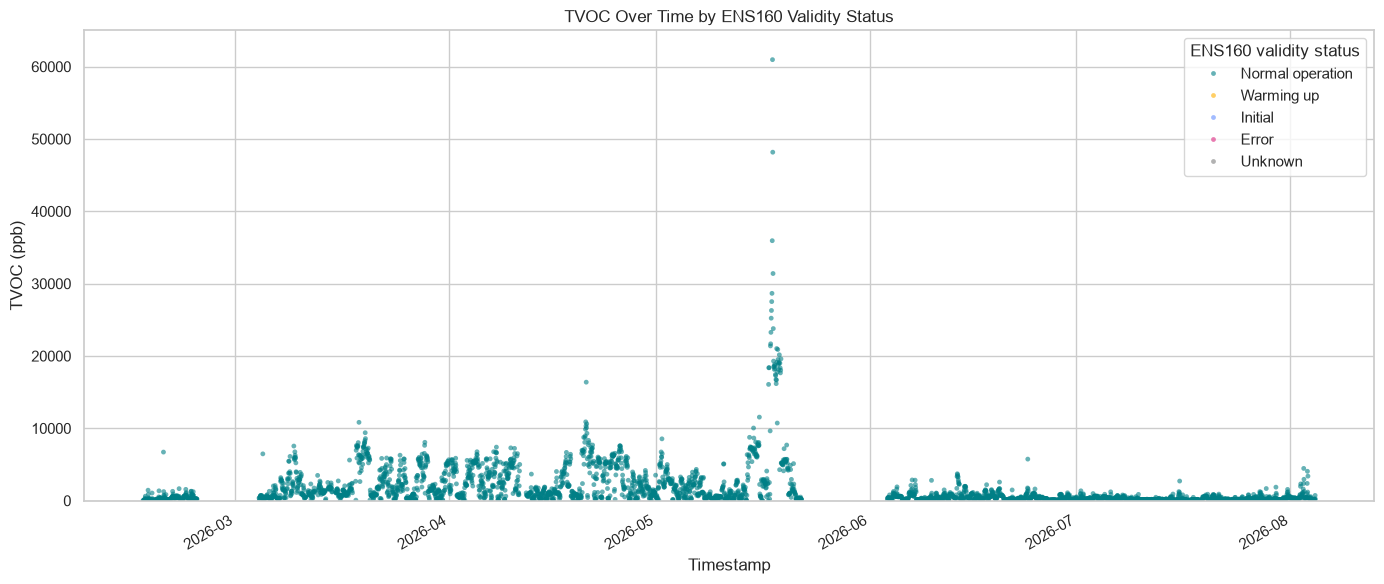

In [15]:
# Plot TVOC readings over time, coloring each point by ENS160 validity status
validity_labels = {
    0: 'Normal operation',
    1: 'Warming up',
    2: 'Initial',
    3: 'Error',
}
validity_colors = {
    'Normal operation': '#007f86',
    'Warming up': '#ffb000',
    'Initial': '#648fff',
    'Error': '#dc267f',
}

tvoc_data = data.dropna(subset=['tvoc_ppb', 'ens_validity']).sort_values('timestamp').copy()
tvoc_data['validity_status'] = tvoc_data['ens_validity'].map(validity_labels).fillna('Unknown')
validity_colors['Unknown'] = '#7f7f7f'

max_points = 4_000
sample_step = max(1, len(tvoc_data) // max_points)
plot_data = tvoc_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=plot_data,
    x='timestamp',
    y='tvoc_ppb',
    hue='validity_status',
    hue_order=[*validity_labels.values(), 'Unknown'],
    palette=validity_colors,
    s=12,
    alpha=0.6,
    linewidth=0,
    ax=ax,
)

ax.set_title('TVOC Over Time by ENS160 Validity Status')
ax.set_xlabel('Timestamp')
ax.set_ylabel('TVOC (ppb)')
ax.set_ylim(tvoc_data['tvoc_ppb'].min() - 1, tvoc_data['tvoc_ppb'].max() + 1)
ax.legend(title='ENS160 validity status')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


## TVOC and eCO2 readings correlation

As mentioned earlier, the TVOC and eCO2 readings are correlated. The correlation can be seen on the scatter plot below, where the x-axis represents the TVOC readings and the y-axis represents the eCO2 readings. The correlation can be seen from the line graph below.

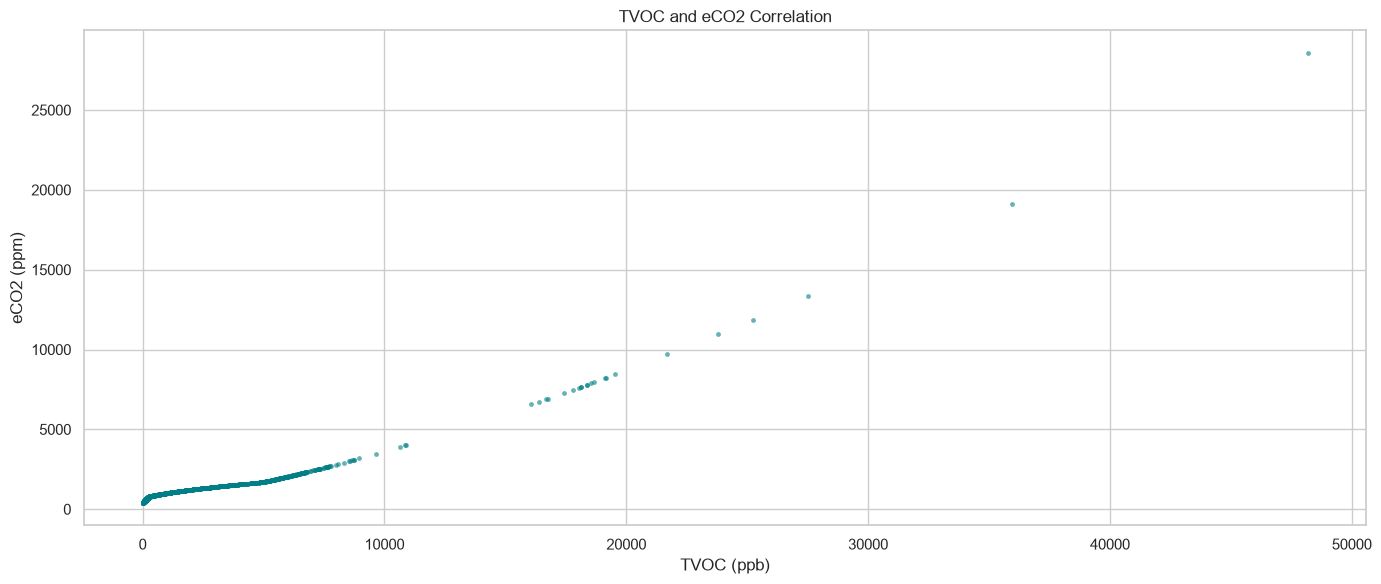

In [16]:
# Plot the tvoc and eco2 readings correlation on the same graph, sampling the data to avoid plotting too many points
correlation_data = data.dropna(subset=['tvoc_ppb', 'eco2_ppm']).sort_values('timestamp')
max_points = 2_000

sample_step = max(1, len(correlation_data) // max_points)
plot_data = correlation_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=plot_data,
    x='tvoc_ppb',
    y='eco2_ppm',
    s=12,
    alpha=0.6,
    linewidth=0,
    color='#007f86',
    ax=ax,
)

ax.set_title('TVOC and eCO2 Correlation')
ax.set_xlabel('TVOC (ppb)')
ax.set_ylabel('eCO2 (ppm)')
fig.tight_layout()
plt.show()


However, TVOC value seems to be more sensitive to changes in the environment, and can peak even when the eCO2 value remains relatively low (but also shows smaller fluctuations). This can be seen on the line graph below.

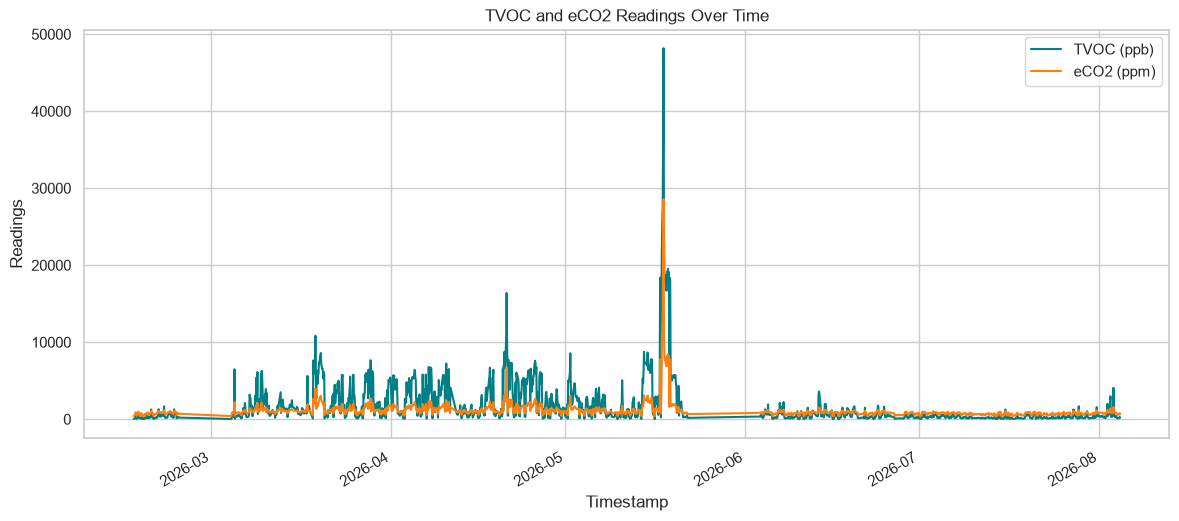

In [17]:
# Plot the tvoc and eco2 readings line graph over time, sampling the data to avoid plotting too many points
line_data = data.dropna(subset=['tvoc_ppb', 'eco2_ppm']).sort_values('timestamp')
max_points = 2_000
sample_step = max(1, len(line_data) // max_points)
plot_line_data = line_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')

fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=plot_line_data,
    x='timestamp',
    y='tvoc_ppb',
    label='TVOC (ppb)',
    color='#007f86',
    ax=ax,
)

sns.lineplot(
    data=plot_line_data,
    x='timestamp',
    y='eco2_ppm',
    label='eCO2 (ppm)',
    color='#ff7f0e',
    ax=ax,
)

ax.set_title('TVOC and eCO2 Readings Over Time')

ax.set_xlabel('Timestamp')
ax.set_ylabel('Readings')
fig.autofmt_xdate()

plt.show()


## Temperature readings

While checking the temperature readings it was discovered that the temperature readings were not accurate. On average the temperature reading measured by the AHT21 sensor was around 3-4°C higher than the actual room temperature measured by an iot thermometer. However the temperature fluctuations produced similar graphs, so the temperature readings can be used to detect changes in the environment. To compute the actual temperature, a calibration factor should be applied to the temperature readings. 

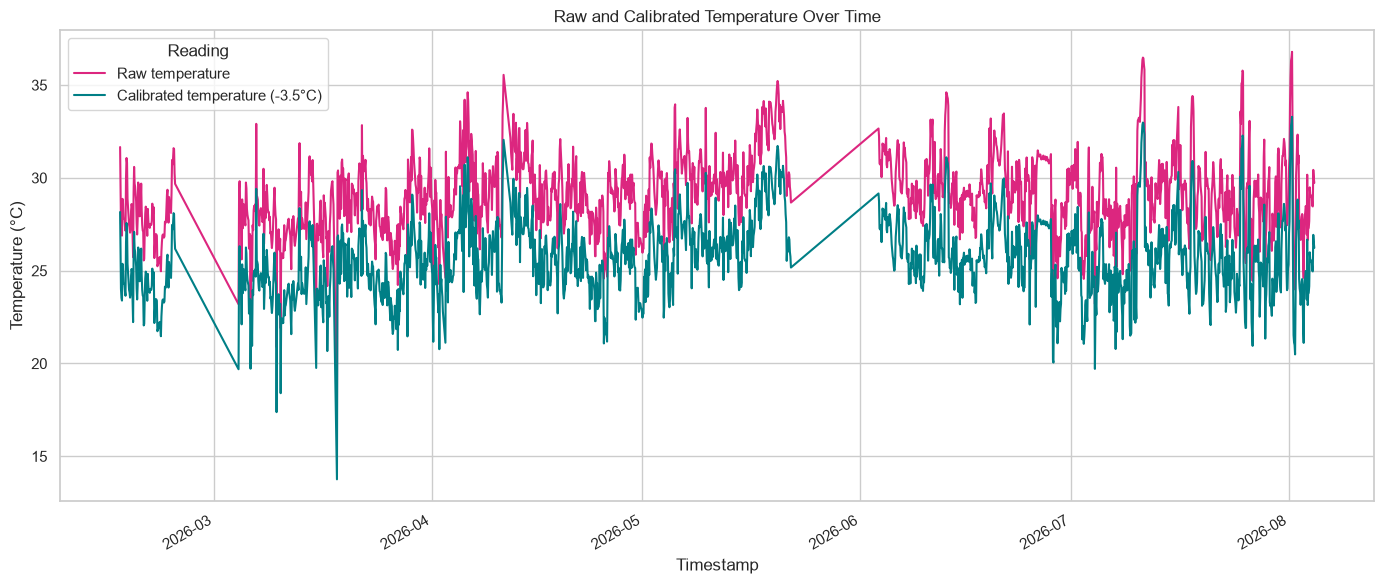

In [18]:
# Plot raw and calibrated temperature readings over time.
calibration_offset_c = 3.5

temperature_data = data.dropna(subset=['temperature_c']).sort_values('timestamp').copy()
temperature_data['calibrated_temperature_c'] = (
    temperature_data['temperature_c'] - calibration_offset_c
)

max_points = 2_000
sample_step = max(1, len(temperature_data) // max_points)
plot_data = temperature_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=plot_data,
    x='timestamp',
    y='temperature_c',
    label='Raw temperature',
    color='#dc267f',
    ax=ax,
)
sns.lineplot(
    data=plot_data,
    x='timestamp',
    y='calibrated_temperature_c',
    label=f'Calibrated temperature (-{calibration_offset_c}°C)',
    color='#007f86',
    ax=ax,
)

ax.set_title('Raw and Calibrated Temperature Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Temperature (°C)')
ax.legend(title='Reading')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


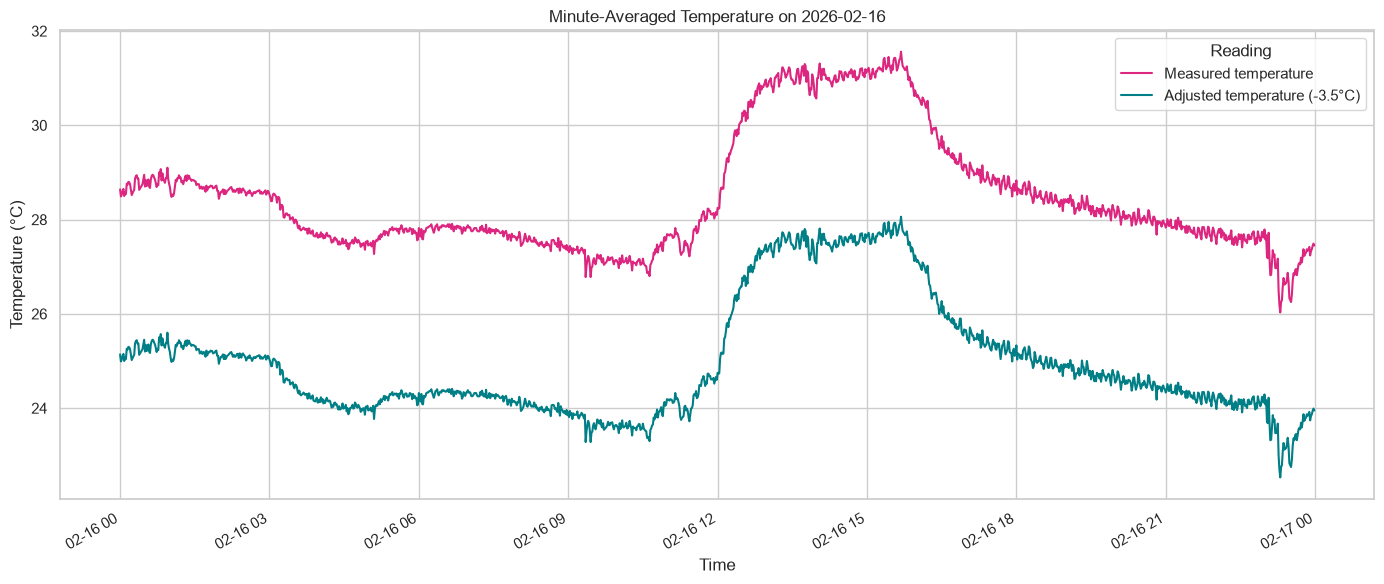

In [19]:
# Plot minute-averaged raw and calibrated temperature readings for the first full day.
calibration_offset_c = 3.5

temperature_data = data.dropna(subset=['temperature_c']).copy()
temperature_data['timestamp'] = pd.to_datetime(temperature_data['timestamp'])
temperature_data = temperature_data.set_index('timestamp').sort_index()

first_full_day = temperature_data.index.normalize().min() + pd.Timedelta(days=1)
day_end = first_full_day + pd.Timedelta(days=1)
one_day_data = temperature_data.loc[
    (temperature_data.index >= first_full_day)
    & (temperature_data.index < day_end)
].copy()
minute_data = one_day_data['temperature_c'].resample('1min').mean().to_frame()
minute_data['calibrated_temperature_c'] = (
    minute_data['temperature_c'] - calibration_offset_c
)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.lineplot(
    data=minute_data,
    x=minute_data.index,
    y='temperature_c',
    label='Measured temperature',
    color='#dc267f',
    ax=ax,
)
sns.lineplot(
    data=minute_data,
    x=minute_data.index,
    y='calibrated_temperature_c',
    label=f'Adjusted temperature (-{calibration_offset_c}°C)',
    color='#007f86',
    ax=ax,
)

ax.set_title(f'Minute-Averaged Temperature on {first_full_day:%Y-%m-%d}')
ax.set_xlabel('Time')
ax.set_ylabel('Temperature (°C)')
ax.legend(title='Reading')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


## The normal and abnormal TVOC and eCO2 readings

To get a better understanding of the of the normal and abnormal sensor readings of the ENS160 we can reference it's documentation. As mentioned in ScioSense datasheet which was referenced earlier, the normal and abnormal readings for CO2 are defined as follows:

| Output | Rating | Comment |
|--------|--------|---------|
| >1500 | <span style="color:red">Bad</span> | Heavy contaminated indoor air / Ventilation required. |
| 1000 - 1500 | <span style="color:orange">Poor</span> | Contaminated indoor air / Ventilation recommended. |
| 800 - 1000 | <span style="color:yellow">Fair</span> | Optional ventilation |
| 600 - 800 | <span style="color:green">Good</span> | Average |
| 400 - 600 | <span style="color: #87CEFA">Excellent</span> | Target |

The AQI and TVOC readings are classified as follows:

| # | Rating | AQI-UBA (mg/m³) | TVOC (ppm) | Hygienic Rating | Recommendation |
|---:|---|---:|---:|---|---|
| 5 | <span style="color:red">Unhealthy</span> | 10 - 25 | 2.2 - 5.5 | Situation not acceptable | Use only if unavoidable<br>Intensified ventilation recommended |
| 4 | <span style="color:orange">Poor</span> | 3 - 10 | 0.65 - 2.2 | Major objections | Intensified ventilation recommended<br>Search for sources |
| 3 | <span style="color:yellow">Moderate</span> | 1 - 3 | 0.22 - 0.65 | Some objections | Increased ventilation recommended<br>Search for sources |
| 2 | <span style="color:green">Good</span> | 0.3 - 1 | 0.065 - 0.22 | No relevant objections | Sufficient ventilation recommended |
| 1 | <span style="color: #87CEFA">Excellent</span> | <0.3 | 0 - 0.065 | No objections | Target |

Let's plot the TVOC and eCO2 readings over time, and mark the normal and abnormal readings on the graph, while limiting the ppm range to 0-4000 ppm for better visualization.

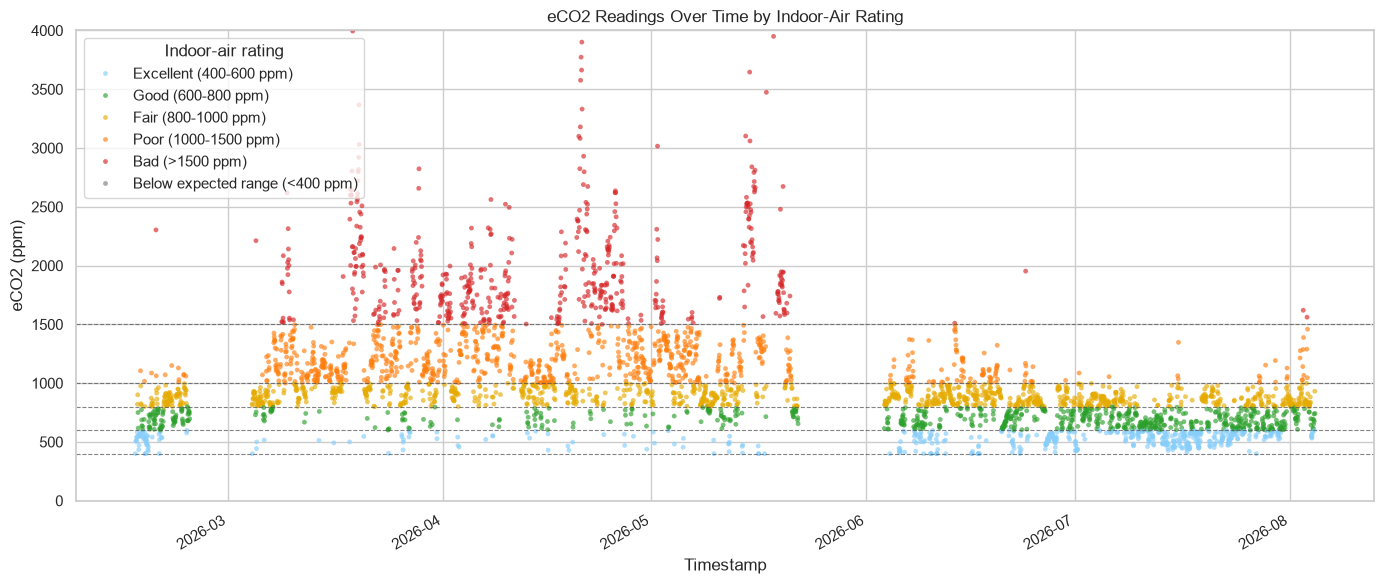

In [ ]:
# Plot eCO2 readings over time, colored by the indoor-air rating bands.
eco2_data = data.dropna(subset=['eco2_ppm']).sort_values('timestamp').copy()

eco2_rating_order = [
    'Excellent (0 - )',
    'Good (600-800 ppm)',
    'Fair (800-1000 ppm)',
    'Poor (1000-1500 ppm)',
    'Bad (>1500 ppm)',
    'Below expected range (<400 ppm)',
]
eco2_colors = {
    'Excellent (400-600 ppm)': '#87cefa',
    'Good (600-800 ppm)': '#2ca02c',
    'Fair (800-1000 ppm)': '#e6ab02',
    'Poor (1000-1500 ppm)': '#ff7f0e',
    'Bad (>1500 ppm)': '#d62728',
    'Below expected range (<400 ppm)': '#7f7f7f',
}

eco2_data['rating'] = pd.cut(
    eco2_data['eco2_ppm'],
    bins=[-np.inf, 400, 600, 800, 1000, 1500, np.inf],
    labels=[
        'Below expected range (<400 ppm)',
        'Excellent (400-600 ppm)',
        'Good (600-800 ppm)',
        'Fair (800-1000 ppm)',
        'Poor (1000-1500 ppm)',
        'Bad (>1500 ppm)',
    ],
    right=False,
)

max_points = 4_000
sample_step = max(1, len(eco2_data) // max_points)
plot_data = eco2_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=plot_data,
    x='timestamp',
    y='eco2_ppm',
    hue='rating',
    hue_order=eco2_rating_order,
    palette=eco2_colors,
    s=12,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)

for threshold in [400, 600, 800, 1000, 1500]:
    ax.axhline(threshold, color='#4d4d4d', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('eCO2 Readings Over Time by Indoor-Air Rating')
ax.set_xlabel('Timestamp')
ax.set_ylabel('eCO2 (ppm)')
ax.set_ylim(bottom=0)
ax.set_ylim(top=4000)
ax.legend(title='Indoor-air rating', loc='upper left')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


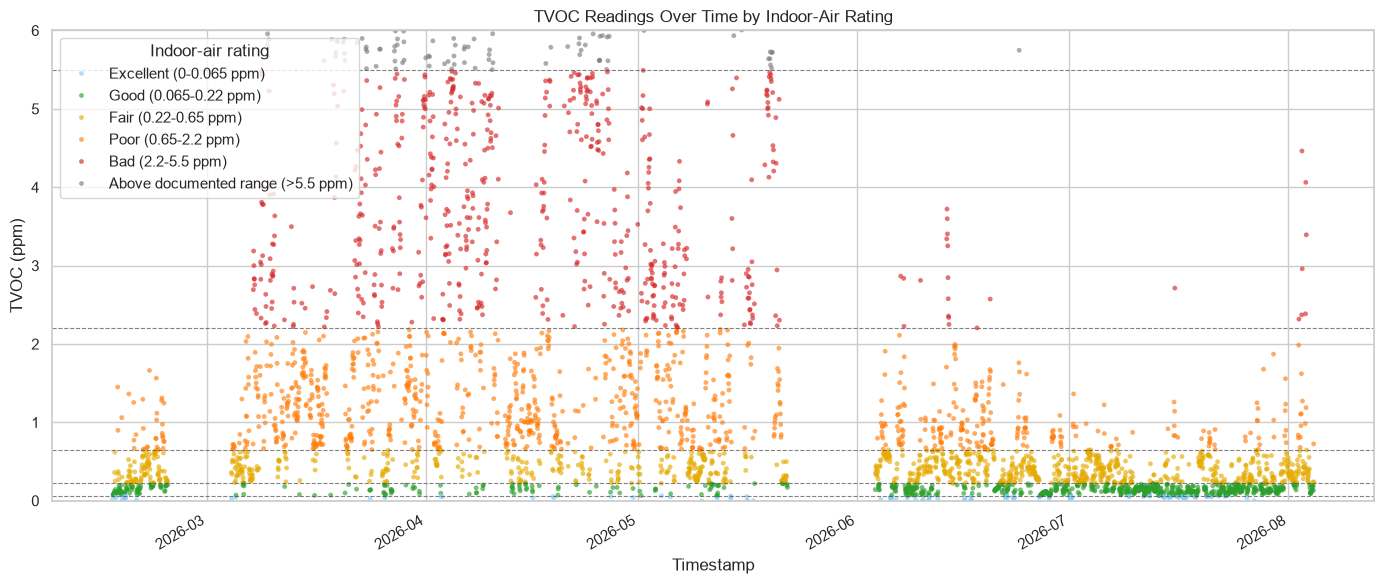

In [26]:
# Plot TVOC readings over time, colored by the indoor-air rating bands.
# TVOC is recorded in ppb; convert it to ppm for the documented rating bands.
tvoc_data = data.dropna(subset=['tvoc_ppb']).sort_values('timestamp').copy()
tvoc_data['tvoc_ppm'] = tvoc_data['tvoc_ppb'] / 1_000

tvoc_rating_order = [
    'Excellent (0-0.065 ppm)',
    'Good (0.065-0.22 ppm)',
    'Fair (0.22-0.65 ppm)',
    'Poor (0.65-2.2 ppm)',
    'Bad (2.2-5.5 ppm)',
    'Above documented range (>5.5 ppm)',
]

tvoc_colors = {
    'Excellent (0-0.065 ppm)': '#87cefa',
    'Good (0.065-0.22 ppm)': '#2ca02c',
    'Fair (0.22-0.65 ppm)': '#e6ab02',
    'Poor (0.65-2.2 ppm)': '#ff7f0e',
    'Bad (2.2-5.5 ppm)': '#d62728',
    'Above documented range (>5.5 ppm)': '#7f7f7f',
}

tvoc_data['rating'] = pd.cut(
    tvoc_data['tvoc_ppm'],
    bins=[-np.inf, 0.065, 0.22, 0.65, 2.2, 5.5, np.inf],
    labels=tvoc_rating_order,
    right=False,
)


max_points = 4_000
sample_step = max(1, len(tvoc_data) // max_points)
plot_data = tvoc_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=plot_data,
    x='timestamp',
    y='tvoc_ppm',
    hue='rating',
    hue_order=tvoc_rating_order,
    palette=tvoc_colors,
    s=12,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)

for threshold in [0.065, 0.22, 0.65, 2.2, 5.5]:
    ax.axhline(threshold, color='#4d4d4d', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('TVOC Readings Over Time by Indoor-Air Rating')
ax.set_xlabel('Timestamp')
ax.set_ylabel('TVOC (ppm)')
ax.set_ylim(bottom=0)
ax.set_ylim(0, 6)
ax.legend(title='Indoor-air rating', loc='upper left')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


Let's also plot the AQI readings over time. The AQI have fixed values from 1 to 5.

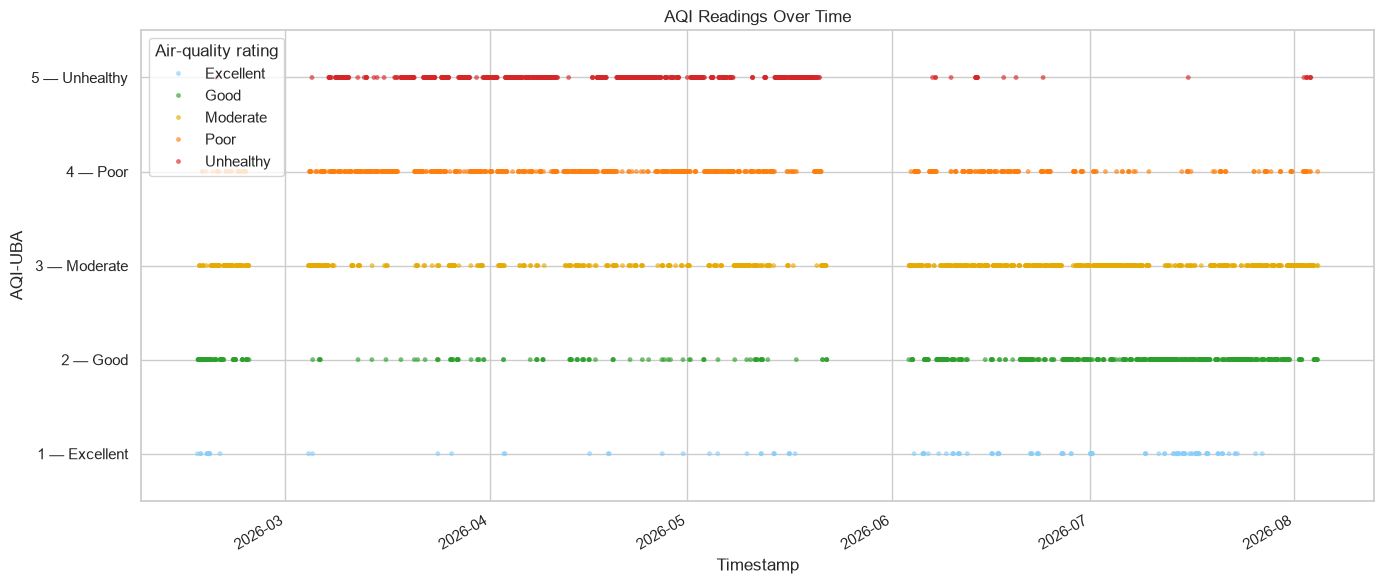

In [27]:
# Plot AQI readings over time, colored by the fixed AQI-UBA categories.
aqi_data = data.dropna(subset=['aqi']).sort_values('timestamp').copy()
aqi_data['aqi'] = aqi_data['aqi'].astype(int)

aqi_labels = {
    1: 'Excellent',
    2: 'Good',
    3: 'Moderate',
    4: 'Poor',
    5: 'Unhealthy',
}
aqi_colors = {
    'Excellent': '#87cefa',
    'Good': '#2ca02c',
    'Moderate': '#e6ab02',
    'Poor': '#ff7f0e',
    'Unhealthy': '#d62728',
}
aqi_order = list(aqi_labels.values())

aqi_data['rating'] = aqi_data['aqi'].map(aqi_labels)

max_points = 4_000
sample_step = max(1, len(aqi_data) // max_points)
plot_aqi_data = aqi_data.iloc[::sample_step]

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

sns.scatterplot(
    data=plot_aqi_data,
    x='timestamp',
    y='aqi',
    hue='rating',
    hue_order=aqi_order,
    palette=aqi_colors,
    s=12,
    alpha=0.65,
    linewidth=0,
    ax=ax,
)

ax.set_title('AQI Readings Over Time')
ax.set_xlabel('Timestamp')
ax.set_ylabel('AQI-UBA')
ax.set_yticks(range(1, 6))
ax.set_yticklabels([f'{value} — {aqi_labels[value]}' for value in range(1, 6)])
ax.set_ylim(0.5, 5.5)
ax.legend(title='Air-quality rating', loc='upper left')
fig.autofmt_xdate()
fig.tight_layout()

plt.show()


An interesting observation is that in some months the AQI readings were mostly in the "Moderate" range, while in other months the readings were mostly in the "Poor" and "Unhealthy" range. Let's plot the bar graph of the AQI readings for each month available in the dataset.

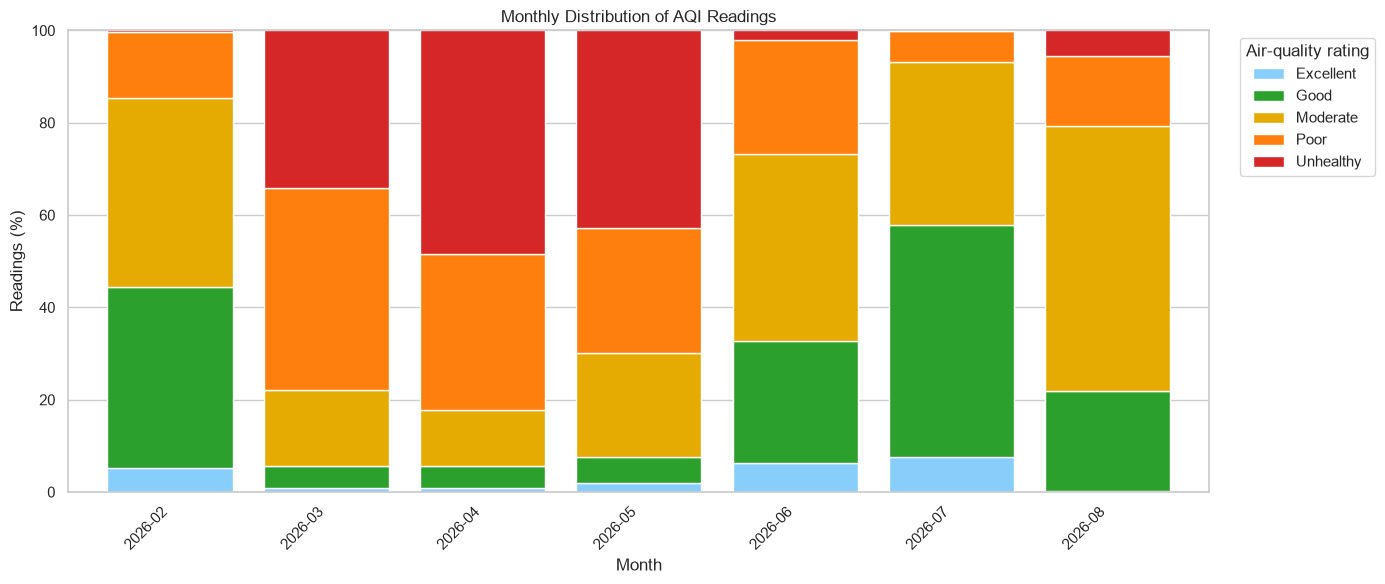

In [28]:
# Plot the monthly distribution of AQI categories as a stacked bar chart.
monthly_aqi_counts = (
    aqi_data.assign(month=aqi_data['timestamp'].dt.to_period('M'))
    .groupby(['month', 'rating'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=aqi_order, fill_value=0)
)

monthly_aqi_percentages = monthly_aqi_counts.div(
    monthly_aqi_counts.sum(axis=1),
    axis=0,
).mul(100)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

monthly_aqi_percentages.plot(
    kind='bar',
    stacked=True,
    color=[aqi_colors[rating] for rating in aqi_order],
    width=0.8,
    ax=ax,
)

ax.set_title('Monthly Distribution of AQI Readings')
ax.set_xlabel('Month')
ax.set_ylabel('Readings (%)')
ax.set_ylim(0, 100)
ax.legend(title='Air-quality rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(
    [str(month) for month in monthly_aqi_percentages.index],
    rotation=45,
    ha='right',
)

fig.tight_layout()
plt.show()


The AQI may not always directly correlate with the TVOC and eCO2 readings, so let's plot similar bar graphs for TVOC and eCO2 readings for each month available in the dataset.

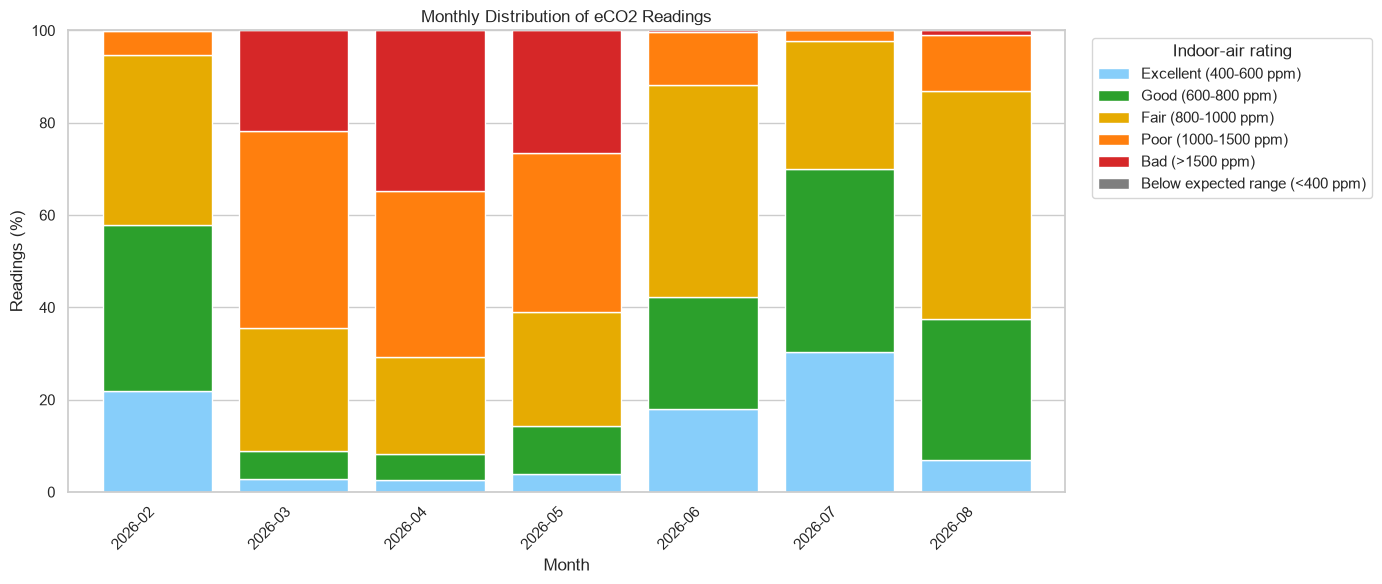

In [29]:
# Plot the monthly distribution of eCO2 indoor-air ratings as a stacked bar chart.
monthly_eco2_counts = (
    eco2_data.assign(month=eco2_data['timestamp'].dt.to_period('M'))
    .groupby(['month', 'rating'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=eco2_rating_order, fill_value=0)
)

monthly_eco2_percentages = monthly_eco2_counts.div(
    monthly_eco2_counts.sum(axis=1),
    axis=0,
).mul(100)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

monthly_eco2_percentages.plot(
    kind='bar',
    stacked=True,
    color=[eco2_colors[rating] for rating in eco2_rating_order],
    width=0.8,
    ax=ax,
)

ax.set_title('Monthly Distribution of eCO2 Readings')
ax.set_xlabel('Month')
ax.set_ylabel('Readings (%)')
ax.set_ylim(0, 100)
ax.legend(title='Indoor-air rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(
    [str(month) for month in monthly_eco2_percentages.index],
    rotation=45,
    ha='right',
)

fig.tight_layout()
plt.show()


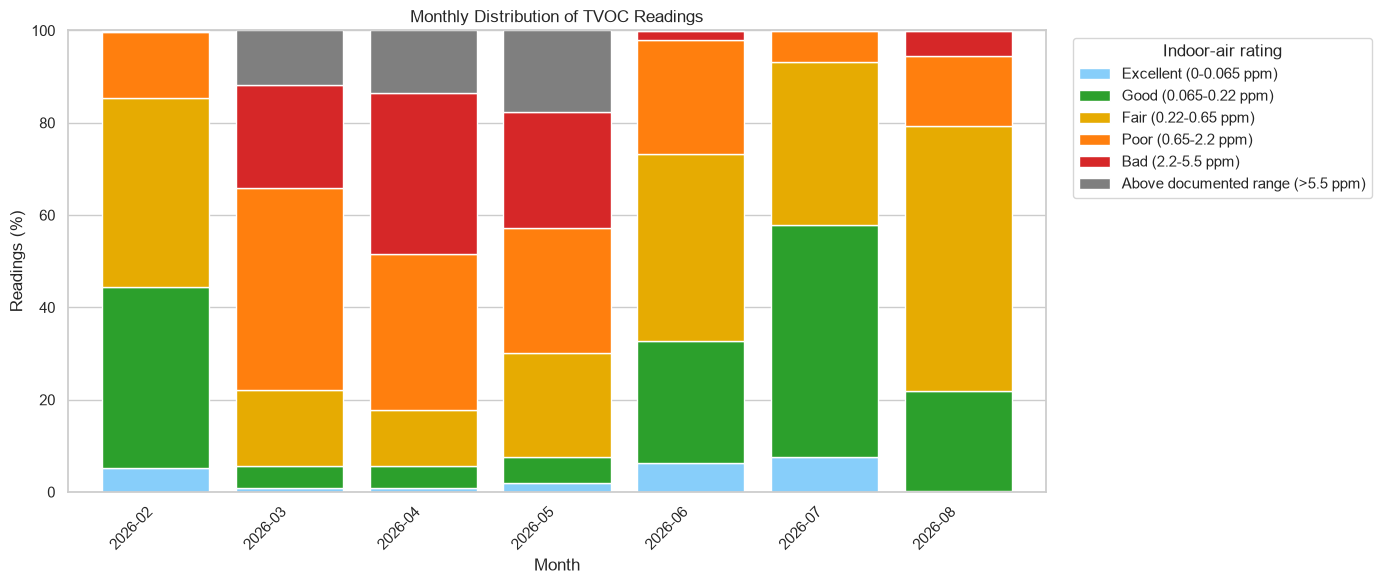

In [30]:
# Plot the monthly distribution of TVOC indoor-air ratings as a stacked bar chart.
monthly_tvoc_counts = (
    tvoc_data.assign(month=tvoc_data['timestamp'].dt.to_period('M'))
    .groupby(['month', 'rating'], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=tvoc_rating_order, fill_value=0)
)

monthly_tvoc_percentages = monthly_tvoc_counts.div(
    monthly_tvoc_counts.sum(axis=1),
    axis=0,
).mul(100)

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(14, 6))

monthly_tvoc_percentages.plot(
    kind='bar',
    stacked=True,
    color=[tvoc_colors[rating] for rating in tvoc_rating_order],
    width=0.8,
    ax=ax,
)

ax.set_title('Monthly Distribution of TVOC Readings')
ax.set_xlabel('Month')
ax.set_ylabel('Readings (%)')
ax.set_ylim(0, 100)
ax.legend(title='Indoor-air rating', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(
    [str(month) for month in monthly_tvoc_percentages.index],
    rotation=45,
    ha='right',
)

fig.tight_layout()
plt.show()


As we can see from the bar graphs, the air quality was worse on a period from March to May, while February, June and July readings were mostly "Good" and "Fair". The are multiple possible reasons for this:
- Ventilation patterns were different during these months.
- The air condition both outside and inside the room has worsened.
- The air condition only inside the room has worsened.

We would like to go through each of these theories one by one to see if we can find any evidence to support or refute them.

### Ventilation patterns

Unfortunately, we do not have any measurements of the ventilation periods, so we cannot directly analyze the impact of ventilation on the air quality readings. However, we can note, that the ventilation generally happened more frequently during the spring months, when it's not too cold or too hot outside.

### Outside air quality

The measurements were taken in a regular apartment room, located in Yokohama city, Japan. The air quality outside the room can be affected by various factors, such as traffic, industrial activities, and weather conditions. As ventilation was done at least once every day, the outside air quality can have a significant impact on the indoor air quality readings.

There are multiple sources of air quality data available for Yokohama city, Japan. We can use this data to analyze the outside air quality during the measurement period and see if there is any correlation with the indoor air quality readings.

